on Google Colab, we sometimes needed to run the
`%pip install merlinquantum` cell and then restart the runtime for the
import to succeed. This was observed on Colab specifically; we have not
tested this on other platforms.

In [2]:
%pip install merlinquantum

In [3]:
import numpy as np

data = np.load("../../data/bve_qnn/sem_supervised_dataset.npz")

print(data.files)

supervised_features = data["supervised_features"]
supervised_targets = data["supervised_targets"]
supervised_targets_normalized = data["supervised_targets_normalized"]
supervised_target_mean = float(data["supervised_target_mean"])
supervised_target_std = float(data["supervised_target_std"])

training_hours = data["training_hours"]
training_time_normalized = data["training_time_normalized"]
lat_downsampled = data["lat_downsampled"]
lon_downsampled = data["lon_downsampled"]
psi_qcl_training = data["psi_qcl_training"]

print("features:", supervised_features.shape)
print("targets normalized:", supervised_targets_normalized.shape)
print("psi_qcl_training:", psi_qcl_training.shape)
print("training_hours:", training_hours)
print("target mean/std:", supervised_target_mean, supervised_target_std)

['supervised_features', 'supervised_targets', 'supervised_targets_normalized', 'supervised_target_mean', 'supervised_target_std', 'training_hours', 'training_time_normalized', 'lat_downsampled', 'lon_downsampled', 'psi_qcl_training', 'psi_sem', 'zeta_sem', 'time_sem_hours', 'zeta_0']
features: (32040, 4)
targets normalized: (32040,)
psi_qcl_training: (8, 45, 89)
training_hours: [ 1  4  7 10 13 16 19 22]
target mean/std: 2732962.9602401294 16100540.426142612


In [4]:
import torch
from torch.utils.data import TensorDataset, DataLoader

In [5]:
#we transform our datas that are numpy arrays in pytorch tensors with batch size = 1602 sampled randomly from the data as the paper says

# # We keep float64 because the quantum model and the physical targets are more stable in float64.
features_tensor = torch.tensor(supervised_features, dtype=torch.float64)
targets_tensor = torch.tensor(supervised_targets, dtype=torch.float64)

dataset = TensorDataset(features_tensor, targets_tensor)
dataloader = DataLoader(dataset, batch_size=1602, shuffle=True)

### QNN configuration with MerLin

The original paper uses a qubit QNN composed of:

1. a feature map encoding the inputs `(t, x, y, z)`,
2. a trainable HEA ansatz,
3. a total magnetisation observable.

In this reproduction, we replace the Qadence qubit implementation by a MerLin
photonic quantum layer (dual-rail encoding). The correspondence is:

- feature map -> MerLin angle encoding (trainable-frequency beam-splitter angles),
- HEA ansatz -> trainable per-qubit dual-rail blocks,
- inter-qubit entanglement (CNOT in the qubit model) -> trainable nearest-neighbour
  beam-splitter mixers, since linear optics has no native two-photon conditional
  gate (KLM theorem). Making these mixers trainable partially compensates for
  this physical limitation, at the cost of extra parameters,
- total magnetisation observable -> photonic dual-rail measurement
  (`<n_left> - <n_right>` per qubit) followed by a trainable classical
  affine readout.



## Parameter count: paper-faithful baseline vs. photonic trainable mixing

In Section V.A, the paper states that Experiment 1 uses a qubit QNN with:

- `N = 6` qubits
- `l = 32` HEA layers
- `P = N(3l + 13)` trainable parameters, i.e. `P = 6 * (3 * 32 + 13) = 654`

In linear optics there is no native two-qubit gate, so here the nearest-neighbour photonic mixers are made trainables. Indeed, in linear optics there is no native two-qubit gate, so here the nearest-neighbour photonic mixers are made trainable
(`theta`, `phi_tr` per mixer) to compensate for this limitation:

```text
extra params = 2 (theta, phi_tr) * (N - 1) mixers/layer * (3 feature-map + 32 HEA) layers
             = 2 * 5 * 35 = 350

total trainable parameters = 654 (paper-faithful) + 350 (trainable mixing) = 1004
```

The photonic model is implemented as a MerLin `QuantumLayer`, which wraps a
custom Perceval circuit. All training, differentiation, and optimization are
handled entirely by MerLin.

We build the circuit directly from Perceval's low-level primitives
(`pcvl.BS`, `pcvl.PS`) instead of MerLin's high-level `CircuitBuilder`,
because the paper's architecture requires precise, mode-level control that
the builder does not expose: per-qubit dual-rail blocks on specific mode
pairs `(2q, 2q+1)`, and nearest-neighbour mixers on specific cross-qubit mode
pairs `(2q+1, 2(q+1))`. This dual-rail circuit is the architectural translation of the paper's neutral atoms model into linear optics.


In [6]:
import math
import torch
import torch.nn as nn
import merlin as ML
import perceval as pcvl
from merlin import ComputationSpace, MeasurementStrategy, QuantumLayer


# main.tex, Section IV:
# The paper maps the original inputs (t, phi, lambda) to (t, x, y, z).
# These are the four classical features embedded into the quantum circuit.
QNN_INPUT_FEATURES = ["t", "x", "y", "z"]


# main.tex, Section V.A:
# Experiment 1 uses N=6 qubits and l=32 HEA layers.
# In MerLin, we encode 6 logical qubits with dual-rail photonics:
# 1 logical qubit = 2 photonic modes, 1 photon.
N_QUBITS = 6
N_MODES = 2 * N_QUBITS
N_PHOTONS = N_QUBITS
DEPTH = 32


def add_dual_rail_single_qubit_block(circuit, qubit, prefix):
    # A dual-rail single-qubit trainable block with 3 parameters.
    # This mirrors the HEA count: 3 trainable parameters per qubit per layer.
    left = 2 * qubit
    right = 2 * qubit + 1

    circuit.add(
        (left, right),
        pcvl.BS(
            theta=pcvl.P(f"{prefix}_theta_q{qubit}"),
            phi_tr=pcvl.P(f"{prefix}_phi_q{qubit}"),
        ),
    )
    circuit.add(left, pcvl.PS(pcvl.P(f"{prefix}_phase_q{qubit}")))


def add_trainable_photonic_mixing(circuit, prefix):
    # Trainable inter-qubit coupling. Compensates for the absence of native
    # CNOT in linear optics (KLM theorem). Adds 2*(N_QUBITS-1) params/layer.
    for qubit in range(N_QUBITS - 1):
        circuit.add(
            (2 * qubit + 1, 2 * (qubit + 1)),
            pcvl.BS(
                theta=pcvl.P(f"{prefix}_mix_theta_q{qubit}"),
                phi_tr=pcvl.P(f"{prefix}_mix_phi_q{qubit}"),
            ),
        )


def build_merlin_dual_rail_circuit():
    circuit = pcvl.Circuit(N_MODES)

    input_index = 1

    # main.tex, Section IV.c-d:
    # Serial trainable-frequency feature map.
    # Qadence version:
    # U_F(r, gamma) = prod_m exp(-i/2 * gamma_{r,m} * Y_m * r)
    #
    # MerLin dual-rail version:
    # each gamma_{r,m} * r is fed as an input-driven beam-splitter angle
    # on logical qubit m.
    for feature_id, feature_name in enumerate(QNN_INPUT_FEATURES):
        for qubit in range(N_QUBITS):
            left = 2 * qubit
            right = 2 * qubit + 1

            circuit.add(
                (left, right),
                pcvl.BS(theta=pcvl.P(f"input{input_index}"), phi_tr=0.0),
            )
            input_index += 1

        # The serial feature map contains 3 trainable ansatz layers between
        # the 4 encoded features: 3 * 3N = 9N parameters.
        if feature_id < 3:
            for qubit in range(N_QUBITS):
                add_dual_rail_single_qubit_block(
                    circuit,
                    qubit,
                    prefix=f"fm_l{feature_id}",
                )
            add_trainable_photonic_mixing(circuit, prefix=f"fm_l{feature_id}")


    # main.tex, Section IV + Section V.A:
    # Main HEA ansatz with l=32 layers.
    # Each layer has 3N trainable parameters.
    for layer in range(DEPTH):
        for qubit in range(N_QUBITS):
            add_dual_rail_single_qubit_block(
                circuit,
                qubit,
                prefix=f"hea_l{layer}",
            )
        add_trainable_photonic_mixing(circuit, prefix=f"hea_l{layer}")


    return circuit


class MerlinDualRailPaperQNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.gamma = nn.Parameter(
            torch.ones(len(QNN_INPUT_FEATURES), N_QUBITS, dtype=torch.float64)
        )

        circuit = build_merlin_dual_rail_circuit()

        self.quantum_layer = QuantumLayer(
            input_size=len(QNN_INPUT_FEATURES) * N_QUBITS,
            circuit=circuit,
            input_state=[1, 0] * N_QUBITS,
            trainable_parameters=["fm", "hea"],
            input_parameters=["input"],
            measurement_strategy=MeasurementStrategy.mode_expectations(
                computation_space=ComputationSpace.DUAL_RAIL
            ),
            dtype=torch.float64,
        )

        # main.tex, Section III:
        # Qubit observable C = sum_m Z_m.
        # Dual-rail equivalent: sum_m (<n_left_m> - <n_right_m>).
        self.register_buffer(
            "magnetisation_weights",
            torch.tensor([1.0, -1.0] * N_QUBITS, dtype=torch.float64),
        )

    def forward(self, features):
        # features has shape (batch_size, 4)
        # columns are exactly: (t, x, y, z)
        if isinstance(features, dict):
            features = torch.stack(
                [features[name] for name in QNN_INPUT_FEATURES],
                dim=-1,
            )

        features = features.to(dtype=torch.float64)

        encoded_features = features.unsqueeze(-1) * self.gamma.unsqueeze(0)
        encoded_features = encoded_features.reshape(features.shape[0], -1)

        mode_expectations = self.quantum_layer(encoded_features)
        raw_output = mode_expectations @ self.magnetisation_weights

        return raw_output


qnn = MerlinDualRailPaperQNN()

number_trainable_parameters = sum(
    parameter.numel()
    for parameter in qnn.parameters()
    if parameter.requires_grad
)

print("MerLin dual-rail QNN built")
print("input features:", QNN_INPUT_FEATURES)
print("logical qubits:", N_QUBITS)
print("photonic modes:", N_MODES)
print("photons:", N_PHOTONS)
print("depth:", DEPTH)
print("trainable parameters:", number_trainable_parameters)
print("expected paper parameters:", N_QUBITS * (3 * DEPTH + 13))

MerLin dual-rail QNN built
input features: ['t', 'x', 'y', 'z']
logical qubits: 6
photonic modes: 12
photons: 6
depth: 32
trainable parameters: 1004
expected paper parameters: 654


We add 2 more trainable parameters than the QNN circuit alone
(1004 -> 1006). This matches Section IV ("Specific architecture choices") of
the original paper:

> "we apply a strategy that will work generally across different problem
> settings by introducing a learnable scaling and shifting to the output of
> the QNN. Therefore, for a particular coordinate QNN(lambda, phi, t), we
> apply the classical learnable linear transformation such that
> psi = alpha_{n-1} * QNN(lambda, phi, t) + alpha_n."

These 2 extra parameters (`output_scale`, `output_shift`, our
`alpha_{n-1}`/`alpha_n`) are the learnable affine readout applied on top of
the photonic magnetisation observable, exactly as in the paper. They are
initialized from the standard deviation and mean of the target data
(`supervised_targets.std()`, `supervised_targets.mean()`), as done in the
original model.

In [7]:
class OutputScaledQNN(nn.Module):
    def __init__(self, qnn, initial_scale, initial_shift):
        super().__init__()

        self.qnn = qnn

        # Learnable affine output map, as described in main.tex:
        # psi = alpha_scale * QNN(lambda, phi, t) + alpha_shift
        self.output_scale = nn.Parameter(
            torch.tensor(float(initial_scale), dtype=torch.float64)
        )
        self.output_shift = nn.Parameter(
            torch.tensor(float(initial_shift), dtype=torch.float64)
        )

    def forward(self, features):
        raw_output = self.qnn(features)

        if raw_output.ndim > 1:
            raw_output = raw_output.squeeze(-1)

        return self.output_scale * raw_output + self.output_shift


model = OutputScaledQNN(
    qnn=qnn,
    initial_scale=supervised_targets.std(),
    initial_shift=supervised_targets.mean(),
)

x_batch, y_batch = next(iter(dataloader))

with torch.no_grad():
    y_pred = model(x_batch)

print("x_batch:", x_batch.shape)
print("y_batch:", y_batch.shape)
print("y_pred:", y_pred.shape)
print("target range:", float(y_batch.min()), float(y_batch.max()))
print("prediction range:", float(y_pred.min()), float(y_pred.max()))
print(
    "qnn trainable parameters:",
    sum(p.numel() for p in qnn.parameters() if p.requires_grad),
)
print(
    "model trainable parameters:",
    sum(p.numel() for p in model.parameters() if p.requires_grad),
)

x_batch: torch.Size([1602, 4])
y_batch: torch.Size([1602])
y_pred: torch.Size([1602])
target range: -26976316.0 42769196.0
prediction range: -21348260.368082292 31097946.74959101
qnn trainable parameters: 1004
model trainable parameters: 1006


### check: input ordering and parameter breakdown

This cell verifies that the input features `(t, x, y, z)` are encoded onto
the circuit in the expected order, and breaks down the 1004 trainable
parameters by block:

- Feature map params (108): gamma trainable frequencies (4 features x
  6 qubits = 24) + 3 feature-map ansatz layers x (18 single-qubit params +
  10 trainable mixer params) = 24 + 3 * 28 = 108.
- HEA params (896): 32 HEA layers x (18 single-qubit params + 10
  trainable mixer params) = 32 * 28 = 896.

Total: 108 + 896 = 1004, matching qnn trainable parameters above

In [8]:
qnn = MerlinDualRailPaperQNN()

spec_mappings = qnn.quantum_layer.computation_process.converter.spec_mappings

expected_input_order = [f"input{i}" for i in range(1, len(QNN_INPUT_FEATURES) * N_QUBITS + 1)]
actual_input_order = spec_mappings["input"]

assert actual_input_order == expected_input_order, (
    "Input parameter order mismatch",
    actual_input_order,
    expected_input_order,
)

assert len(spec_mappings["fm"]) == 3 * 3 * N_QUBITS + 2 * (N_QUBITS - 1) * 3
assert len(spec_mappings["hea"]) == DEPTH * 3 * N_QUBITS + 2 * (N_QUBITS - 1) * DEPTH

print("input order checked")
print("feature map params:", len(spec_mappings["fm"]) + qnn.gamma.numel())
print("HEA params:", len(spec_mappings["hea"]))

input order checked
feature map params: 108
HEA params: 896


In [9]:
import os

save_dir = "models"
os.makedirs(save_dir, exist_ok=True)

In [10]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
loss_fn = nn.MSELoss()

checkpoint_path = "models/qnn_exp1_merlin_dualrail_depth32_step5000.pt"
checkpoint = torch.load(checkpoint_path, map_location="cpu")

model.load_state_dict(checkpoint["model_state_dict"])
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
loss_history = checkpoint["loss_history"]

print("loaded step:", checkpoint["step"])
print("loss history length:", len(loss_history))
print("last loss:", loss_history[-1])

loaded step: 5000
loss history length: 5000
last loss: 4187451236692.4624


Unlike the initial training cell, this loop can resume from an existing
`loss_history` (after a Colab runtime disconnect) instead of restarting
at step 0: `start_step = len(loss_history)`, and the loop continues up to
`TARGET_TOTAL_STEPS = 5000`. This is functionally equivalent to the paper's
training procedure (Adam, lr = 1e-2, batch size 1602, 5000 iterations,
Section V.A). It just tolerates interruptions without losing prior progress.
Checkpoints are saved every `CHECKPOINT_EVERY` steps to
`qnn_exp1_merlin_dualrail_depth32_step{global_step}.pt`.

In [11]:
TARGET_TOTAL_STEPS = 5000
CHECKPOINT_EVERY = 500
PRINT_EVERY = 100

print("starting from:", len(loss_history))

data_iterator = iter(dataloader)
model.train()

start_step = len(loss_history)

for global_step in range(start_step + 1, TARGET_TOTAL_STEPS + 1):
    try:
        x_batch, y_batch = next(data_iterator)
    except StopIteration:
        data_iterator = iter(dataloader)
        x_batch, y_batch = next(data_iterator)

    optimizer.zero_grad()

    y_pred = model(x_batch)
    loss = loss_fn(y_pred, y_batch)

    loss.backward()
    optimizer.step()

    loss_history.append(float(loss.detach()))

    if global_step % PRINT_EVERY == 0 or global_step == TARGET_TOTAL_STEPS:
        print(f"step {global_step:04d} | loss = {loss_history[-1]:.6e}")

    if global_step % CHECKPOINT_EVERY == 0 or global_step == TARGET_TOTAL_STEPS:
        checkpoint = {
            "architecture": "merlin_dualrail_photonic",
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "loss_history": loss_history,
            "step": global_step,
            "depth": DEPTH,
            "n_qubits": N_QUBITS,
            "n_params": 1006,
        }

        checkpoint_path = os.path.join(
            save_dir,
            f"qnn_exp1_merlin_dualrail_depth32_step{global_step}.pt",
        )

        torch.save(checkpoint, checkpoint_path)
        print("checkpoint saved:", checkpoint_path)

starting from: 5000


### check: final training loss (MSE), compared to our qubit reproduction

The paper defines the training loss as the MSE between prediction and
reference data (Section V.A): "The loss function is simply the MSE of the
model prediction compared to the reference data,
L = MSE(psi_tilde, psi)." The paper does not report a target MSE/RMSE value,
so this is not compared against a paper baseline. Instead, we compare it
against our own qubit reproduction (`running_exp1 (4).ipynb`), using the
exact same computation over the full dataset:

| Model                  | normalized RMSE |
|-------------------------|-----------------|
| Neutral atoms (Qadence)     | 7.57%           |
| Photonic (MerLin)   | 12.77%          |

The photonic model's error is about **1.7x higher** than the qubit model's.
This is consistent with the same gap already observed on the paper's official
figures of merit (MRE: 14.85% vs 9.15%, a 1.62x ratio; PPMCC: 0.754 vs 0.873),
confirming the same underlying cause: the lack of a native entangling gate in
linear optics, only partially compensated by trainable beam-splitter mixing.

In [12]:
model.eval()

with torch.no_grad():
    y_pred_all = model(features_tensor)
    mse = torch.mean((y_pred_all - targets_tensor) ** 2)
    rmse = torch.sqrt(mse)
    normalized_rmse = rmse / targets_tensor.std()

print("MSE:", float(mse))
print("RMSE:", float(rmse))
print("normalized RMSE:", float(normalized_rmse))

MSE: 4226660422240.875
RMSE: 2055884.3406769931
normalized RMSE: 0.12768840069489715


Once training is complete, we record the predicted stream function for each point in space and time.

In [13]:
model.eval()

with torch.no_grad():
    psi_pred_flat = model(features_tensor).detach().cpu().numpy()

psi_pred_training = psi_pred_flat.reshape(8, 45, 89)

print("psi_pred_training:", psi_pred_training.shape)
print("psi_qcl_training:", psi_qcl_training.shape)

psi_pred_training: (8, 45, 89)
psi_qcl_training: (8, 45, 89)


The paper reports a median MRE between 7.1% and 10.9% for the original
qubit-based QNN. The neutral atoms reproduction
reaches 9.15%, within this range.

Our MerLin dual-rail photonic version
reaches a median MRE of 14.85%, with visually similar large-scale
stream-function patterns. This is about 1.6x
higher than our qubit reproduction, consistent with the gap already observed
on the global MSE/RMSE sanity check (12.77% vs 7.57% normalized RMSE, a 1.7x
ratio). Both point to the same underlying cause: linear optics has no native
two-qubit entangling gate (KLM theorem), so even with trainable
beam-splitter mixing, the photonic model cannot fully match the qubit
model's expressivity.

While this does not match the paper's reported accuracy, it demonstrates
that a photonic dual-rail QNN can learn the global stream-function dynamics
of a real-world weather PDE

In [14]:
# Appendix FOM of main.tex:
# MRE = mean(|psi_NN - psi_SEM| / median(|psi_SEM|))
# computed separately for each time snapshot.

mre_per_time = []

for k in range(len(training_hours)):
    psi_nn = psi_pred_training[k]
    psi_sem_ref = psi_qcl_training[k]

    sem_median_abs = np.median(np.abs(psi_sem_ref))
    mre = np.mean(np.abs(psi_nn - psi_sem_ref) / sem_median_abs)

    mre_per_time.append(mre)

mre_per_time = np.array(mre_per_time)

print("training_hours:", training_hours)
print("MRE per time:", mre_per_time)
print("MRE percent per time:", 100 * mre_per_time)
print("median MRE percent:", 100 * np.median(mre_per_time))

training_hours: [ 1  4  7 10 13 16 19 22]
MRE per time: [0.20962865 0.17410244 0.14941417 0.1369262  0.13438169 0.13709092
 0.1475212  0.16545361]
MRE percent per time: [20.96286534 17.41024375 14.94141714 13.69262014 13.43816901 13.70909203
 14.75211997 16.54536096]
median MRE percent: 14.846768555830813


The paper reports a median PPMCC of 0.870 for the original qubit-based QNN.
The version with neutral atoms reaches 0.873, matching
the paper result.

Our MerLin dual-rail photonic version (v3, trainable entangling mixers)
reaches a median PPMCC of 0.754. This shows the photonic model successfully captures the main
temporal correlations of the global stream-function dynamics, even though it
does not yet fully match the neutral atoms implementation. As with the MRE
result above, this gap is consistent with the absence of a native photonic
entangling gate (KLM theorem); trainable
beam-splitter mixing already brings the photonic model's correlation close
to the neutral atoms performance, confirming MerLin as a viable framework
for photonic quantum scientific machine learning.

In [15]:
# Appendix FOM of main.tex:
# PPMCC is computed per spatial grid point over the time dimension.
# Then we summarize it using the median over all grid points.

psi_nn_time_space = psi_pred_training.reshape(len(training_hours), -1)
psi_sem_time_space = psi_qcl_training.reshape(len(training_hours), -1)

ppmcc_per_grid_point = []

for j in range(psi_nn_time_space.shape[1]):
    nn_series = psi_nn_time_space[:, j]
    sem_series = psi_sem_time_space[:, j]

    if np.std(nn_series) == 0 or np.std(sem_series) == 0:
        ppmcc = np.nan
    else:
        ppmcc = np.corrcoef(nn_series, sem_series)[0, 1]

    ppmcc_per_grid_point.append(ppmcc)

ppmcc_per_grid_point = np.array(ppmcc_per_grid_point)

print("median PPMCC:", np.nanmedian(ppmcc_per_grid_point))

median PPMCC: 0.7537692910267572


In [16]:
!pip install cartopy

In [17]:
np.savez(
    "exp1_merlin_results.npz",
    psi_pred_training=psi_pred_training,
    psi_qcl_training=psi_qcl_training,
    training_hours=training_hours,
    mre_per_time=mre_per_time,
    ppmcc_per_grid_point=ppmcc_per_grid_point,
    median_mre_percent=100 * np.median(mre_per_time),
    median_ppmcc=np.nanmedian(ppmcc_per_grid_point),
)
print("saved exp1_merlin_results.npz")
print("median MRE percent:", 100 * np.median(mre_per_time))
print("median PPMCC:", np.nanmedian(ppmcc_per_grid_point))

saved exp1_merlin_results.npz
median MRE percent: 14.846768555830813
median PPMCC: 0.7537692910267572


### Reproducing the paper's Figure

This reproduces the paper's Figure ("Prediction of global stream function
psi after t=22 hours of evolution by SEM (left) or trained quantum model
(right)", Section V.A), using our photonic MerLin model in place of the
paper's neutral atoms QNN.


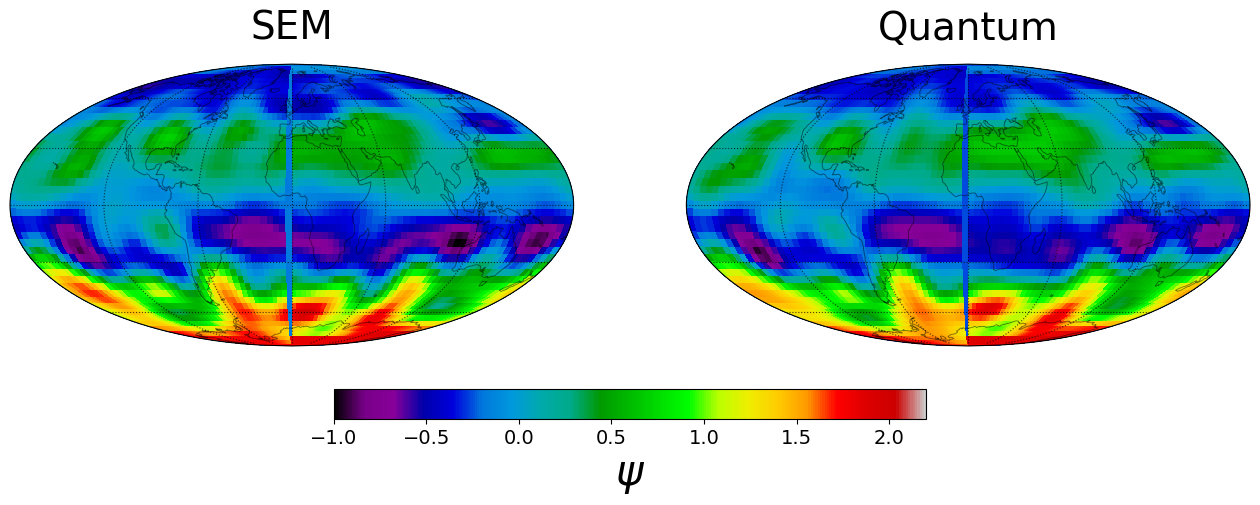

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Load saved Exp1 predictions/results.
exp1_results = np.load("exp1_merlin_results.npz")

psi_pred_training = exp1_results["psi_pred_training"]
psi_qcl_training = exp1_results["psi_qcl_training"]
training_hours = exp1_results["training_hours"]

# Load lat/lon from the SEM dataset.
sem_data = np.load("../../data/bve_qnn/sem_supervised_dataset.npz")
lat_downsampled = sem_data["lat_downsampled"]
lon_downsampled = sem_data["lon_downsampled"]

# Paper figure: t = 22 h.
target_hour = 22
target_index = np.where(training_hours == target_hour)[0][0]

psi_sem_t22 = psi_qcl_training[target_index]
psi_qnn_t22 = psi_pred_training[target_index]

# Visual scaling only, to mimic the paper colorbar around [-1, 2].
# Metrics should still use raw psi, not this scaled version.
psi_min = psi_sem_t22.min()
psi_max = psi_sem_t22.max()

psi_sem_plot = 3.0 * (psi_sem_t22 - psi_min) / (psi_max - psi_min) - 1.0
psi_qnn_plot = 3.0 * (psi_qnn_t22 - psi_min) / (psi_max - psi_min) - 1.0

lon_grid, lat_grid = np.meshgrid(lon_downsampled, lat_downsampled)

projection = ccrs.Mollweide(central_longitude=0)
data_crs = ccrs.PlateCarree()

fig = plt.figure(figsize=(16, 7))

ax_sem = fig.add_subplot(1, 2, 1, projection=projection)
ax_qnn = fig.add_subplot(1, 2, 2, projection=projection)

for ax, field, title in [
    (ax_sem, psi_sem_plot, "SEM"),
    (ax_qnn, psi_qnn_plot, "Quantum"),
]:
    mesh = ax.pcolormesh(
        lon_grid,
        lat_grid,
        field,
        transform=data_crs,
        cmap="nipy_spectral",
        vmin=-1.0,
        vmax=2.2,
        shading="auto",
    )

    ax.set_global()
    ax.gridlines(
        draw_labels=False,
        linewidth=0.8,
        color="black",
        alpha=0.7,
        linestyle=":",
    )
    ax.coastlines(linewidth=0.6, alpha=0.5)
    ax.set_title(title, fontsize=28, pad=18)

cbar = fig.colorbar(
    mesh,
    ax=[ax_sem, ax_qnn],
    orientation="horizontal",
    fraction=0.055,
    pad=0.08,
)

cbar.set_label(r"$\psi$", fontsize=30)
cbar.ax.tick_params(labelsize=14)

plt.savefig("exp1_real_data_comparison_t22_cartopy.png", dpi=250, bbox_inches="tight")
plt.show()